# Testing Noise Model On ***Phase Flip*** Error Correction Code

In [9]:
# Typical imports

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')    # Use dark background for plots

import qibo
assert qibo.__version__ >= "0.2.20", "This script requires qibo version 0.2.20 or higher."

from qibo import Circuit, gates
from qibo.result import CircuitResult
from qibo.gates import *

from qibo.ui import plot_circuit, plot_density_hist, visualize_state
from qibo.ui.drawing_utils import QIBO_COMPLEMENTARY_COLOR, QIBO_DEFAULT_COLOR, generate_bitstring_combinations

### Import QEC module ###
from qibo_qec import QEC

custom_style = {                    # Define a custom style for the circuit plot
    "facecolor" : "#000000",
    "edgecolor" : "#ffffff",
    "linecolor" : "#ffffff",
    "textcolor" : "#ffffff",
    "fillcolor" : "#c41b1b",
    "gatecolor" : "#9000ff",
    "controlcolor" : "#360000"
}

Importing Noise Model from Qibo

In [10]:
from qibo.noise import NoiseModel, PauliError, PhaseDampingError, DepolarizingError, AmplitudeDampingError

## Compare Noise with and without Error Correction

Define noise model with Bit Flip Error as a Pauli X gate with certain error probability

Apply noise model to the circuits

Initialized QEC with code type: phase_flip


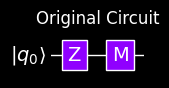

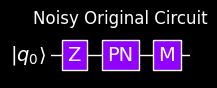

In [11]:
# Create a QEC object for Bit-Flip code
qec = QEC(code_type="phase_flip")

# Define a simple circuit
qc = Circuit(1)
qc.add( [ gates.Z(0), gates.M(0)] )
plot_circuit(qc, style=custom_style)
plt.title("Original Circuit")
plt.show()

# Probability of bit-flip error
error_rate = 0.2

# Define noise model with Bit Flip Error as a Pauli X gate with certain error probability
noise_model = NoiseModel()
noise_model.add(PauliError([("Z", error_rate)]), gates.Z, 0)

# Apply noise model to original and QEC encoded circuits
qc_noisy = noise_model.apply(qc)
plot_circuit(qc_noisy, style=custom_style)
plt.title("Noisy Original Circuit")
plt.show()

Applying phase_flip code to a circuit with 3 qubit(s).


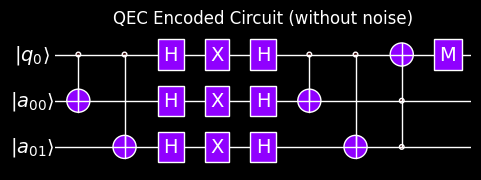

In [12]:
# Apply QEC encoding to the circuit
qc_qec = qec.apply_code(qc)
plot_circuit(qc_qec, style=custom_style)
plt.title("QEC Encoded Circuit (without noise)")
plt.show()

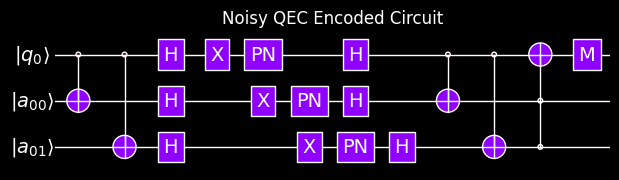

In [13]:
error_rate_qec = 0.1  
noise_model_qec = NoiseModel()
noise_model_qec.add(PauliError([("Z", error_rate_qec)]), gates.X)  # Apply noise to the first qubit of the encoded circuit

# Apply noise model to QEC encoded circuit
qc_qec_noisy = noise_model_qec.apply(qc_qec)
plot_circuit(qc_qec_noisy, style=custom_style)
plt.title("Noisy QEC Encoded Circuit")
plt.show()

## Simulated Ideal Circuit with no Noise

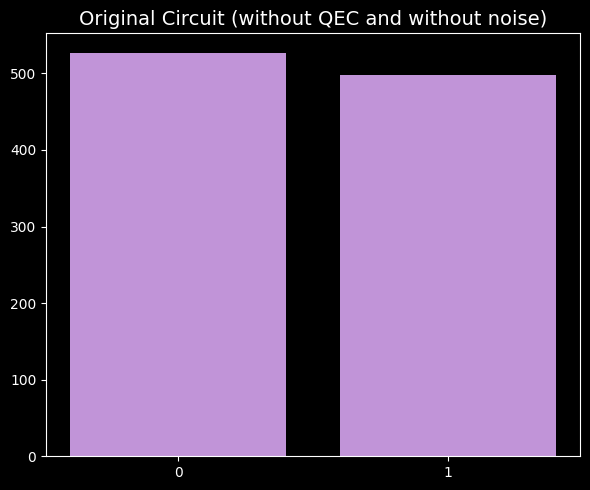

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.set_title("Original Circuit (without QEC and without noise)", fontsize=14)

init = 1/np.sqrt(2) * np.array([1, 1])
result_og = qc(initial_state=init, nshots=2**10)
ax.bar(result_og.frequencies().keys(), result_og.frequencies().values(), color=QIBO_DEFAULT_COLOR)
plt.tight_layout()
plt.show()

## Simulated Circuit with Noise

Applying phase_flip code to a circuit with 3 qubit(s).


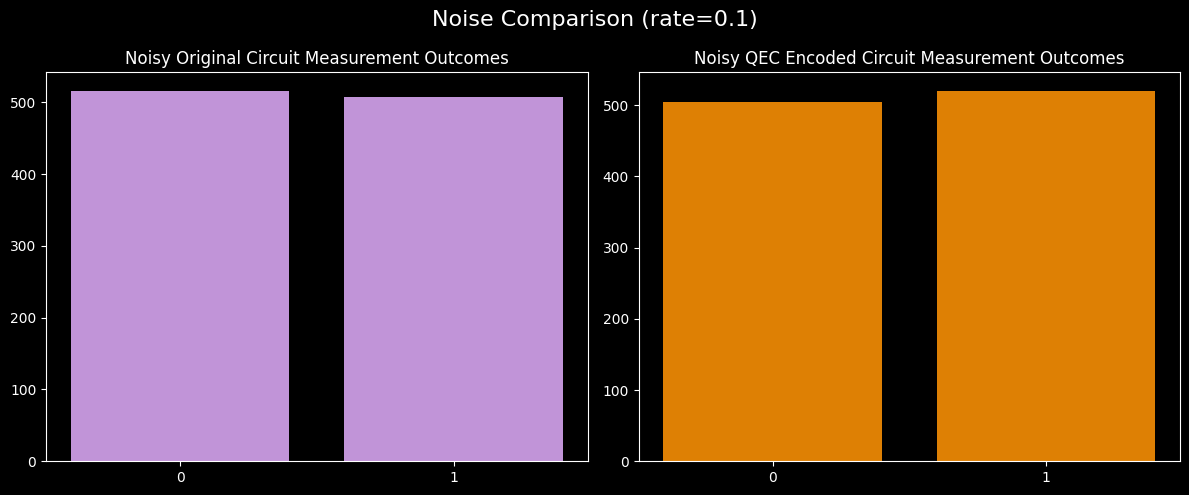

In [17]:
qc = Circuit(1)
qc.add( [ gates.Z(0), gates.M(0)] )
qc_qec = qec.apply_code(qc)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Noise Comparison (rate={error_rate})", fontsize=16)

error_rate = 0.1

# Define noise model with Bit Flip Error as a Pauli X gate with certain error probability
noise_model = NoiseModel()
noise_model.add(PauliError([("Z", error_rate)]), gates.Z, 0)

# Apply noise model to original circuit
qc_noisy = noise_model.apply(qc)
init = 1/np.sqrt(2) * np.array([1, 1])
result = qc_noisy(initial_state=init,nshots=2**10)

ax[0].set_title("Noisy Original Circuit Measurement Outcomes")
ax[0].bar(result.frequencies().keys(), result.frequencies().values(), color=QIBO_DEFAULT_COLOR)


noise_model_qec = NoiseModel()
noise_model_qec.add(PauliError([("Z", error_rate)]), gates.X, 0)  # Apply noise to the first qubit of the encoded circuit
    
# Apply noise model to QEC encoded circuit
qc_qec_noisy = noise_model_qec.apply(qc_qec)
result_qec = qc_qec_noisy(initial_state=init, nshots=2**10)

ax[1].set_title("Noisy QEC Encoded Circuit Measurement Outcomes")
ax[1].bar(result_qec.frequencies().keys(), result_qec.frequencies().values(), color=QIBO_COMPLEMENTARY_COLOR)

plt.tight_layout()
plt.show()

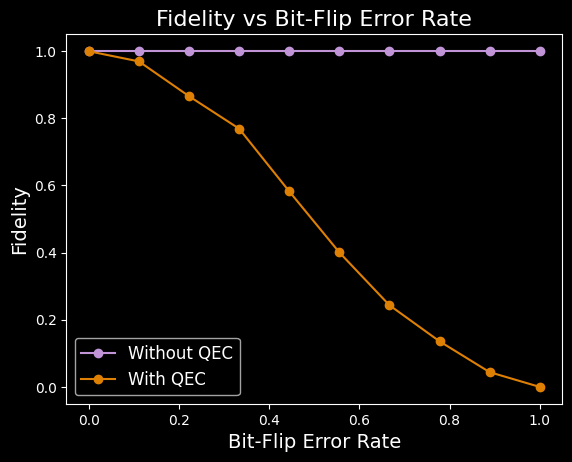

In [18]:
ranges = np.linspace(0, 1, 10)

fidelitys_no_qec = []
fidelitys_qec = []

for i in ranges:

    # Define noise model with Bit Flip Error as a Pauli X gate with certain error probability
    noise_model = NoiseModel()
    noise_model.add(PauliError([("Z", i)]), gates.Z, [0,1,2])
    
    qc_noisy = noise_model.apply(qc)
    result = qc_noisy(nshots=2**10)

    fidelitys_no_qec.append( result.probabilities()[0] )

    # Apply noise model to QEC encoded circuit
    noise_model_qec = NoiseModel()
    noise_model_qec.add(PauliError([("Z", i)]), gates.X, [0,1,2])  # Apply noise to the first qubit of the encoded circuit
    qc_qec_noisy = noise_model_qec.apply(qc_qec)
    
    result_qec = qc_qec_noisy(nshots=2**10)

    fidelitys_qec.append( result_qec.probabilities()[0] )

    # print("Fidelities :", result.probabilities()[0], result_qec.probabilities()[0])

plt.title("Fidelity vs Bit-Flip Error Rate", fontsize=16)
plt.plot(ranges, fidelitys_no_qec, label="Without QEC", color=QIBO_DEFAULT_COLOR, marker='o')
plt.plot(ranges, fidelitys_qec, label="With QEC", color=QIBO_COMPLEMENTARY_COLOR, marker='o')
plt.xlabel("Bit-Flip Error Rate", fontsize=14)
plt.ylabel("Fidelity", fontsize=14)
plt.legend(fontsize=12)
plt.show()